# A sample practices to get data and operate on Python for descriptive statistical analysis.

In [ ]:
# First, make sure you have openpyxl installed
!pip install openpyxl

In [1]:
import pandas as pd
import numpy as np

In [2]:
# prompt: connect Google drive and load data to work
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/data/Teaching/Boxplot Z-score and Outlier.xlsx'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# prompt: load only a certain number of rows.

import pandas as pd
df = pd.read_excel(file_path,
                   sheet_name='Growth_Value',
                   usecols=[0,1,2],
                   nrows=36) # Reads only the first 10 rows


In [4]:
# prompt: to force column o from excel to be date-time format
df['Year'] = pd.to_numeric(df['Year'].astype('int'))
df.set_index('Year', inplace=True)


In [20]:
df

,Growth_Invest,Value_Invest,Growth_Invest_zscore,Value_Invest_zscore
Year,,,,
1984,-5.50,-8.59,-0.865031,-1.118013
1985,39.91,22.10,1.041129,0.594618
1986,13.03,14.74,-0.087203,0.183899
1987,-1.70,-8.58,-0.705519,-1.117455
1988,16.05,29.05,0.039566,0.982457
1989,41.64,22.95,1.113748,0.642051
1990,3.59,-12.82,-0.483463,-1.354065
1991,48.33,26.20,1.394572,0.823415
1992,7.94,21.15,-0.300865,0.541604


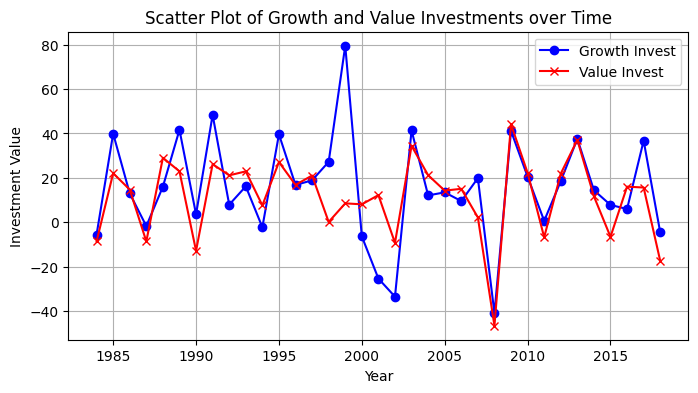

In [14]:
#Scatter plots of the values of growth and value against time

plt.figure(figsize=(8, 4))

plt.plot(df.index, df['Growth_Invest'], label='Growth Invest', marker='o', color='blue')

plt.plot(df.index, df['Value_Invest'], label='Value Invest', marker='x', color='red')

plt.xlabel('Year')
plt.ylabel('Investment Value')
plt.title('Scatter Plot of Growth and Value Investments over Time')
plt.legend()
plt.grid(True)
plt.show()


Section 1: Descriptive stas of Mean, Median and Mode.

In [21]:
#Mean
print(f"Mean of Growth invest {df['Growth_Invest'].mean()} \n\
Mean of Value Invest {df['Value_Invest'].mean()}")

Mean of Growth invest 15.10742857142857 
Mean of Value Invest 11.44457142857143


In [22]:
#Median
print(f"Median of Growth invest {df['Growth_Invest'].median()} \n\
Median of Value Invest {df['Value_Invest'].median()}")

Median of Growth invest 14.44 
Median of Value Invest 15.09


In [23]:
#Mode
print(f"Mode of Growth invest {df['Growth_Invest'].mode()[0]} \n\
Mode of Value Invest {df['Value_Invest'].mode()[0]}")


Mode of Growth invest -40.9 
Mode of Value Invest -46.52


In [24]:
#Just to observe when frequency is flat, the first item is obtained.
value, count = np.unique(df['Growth_Invest'], return_counts=True)


In [59]:
print(f"value {value} \n\ count {count}")

value [-40.9  -33.45 -25.31  -6.32  -5.5   -4.53  -2.22  -1.7    0.67   3.59
   6.01   7.83   7.94   9.56  12.12  13.03  13.5   14.44  16.05  16.19
  16.81  18.52  18.91  19.89  20.55  27.23  36.76  37.61  39.61  39.91
  41.15  41.36  41.64  48.33  79.48] 
\ count [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [25]:
#mode() is a function of pandas, so we cannot apply it to list.
pd.DataFrame([0,3,3,4,6,7,7,9]).mode()

,0
0,3
1,7


Section 2: Location measures

In [26]:
# Calculate percentiles for Growth_Invest
print("Percentiles for Growth_Invest:")
for p in [0, 25, 50, 75, 100]:
    percentile_value = np.percentile(df['Growth_Invest'], p)
    print(f"{p}th percentile: {percentile_value:.2f}")

# Calculate percentiles for Value_Invest
print("\nPercentiles for Value_Invest:")
for p in [0, 25, 50, 75, 100]:
    percentile_value = np.percentile(df['Value_Invest'], p)
    print(f"{p}th percentile: {percentile_value:.2f}")
# Note that percentile 50 = Median value.

Percentiles for Growth_Invest:
0th percentile: -40.90
25th percentile: 2.13
50th percentile: 14.44
75th percentile: 31.99
100th percentile: 79.48

Percentiles for Value_Invest:
0th percentile: -46.52
25th percentile: 1.20
50th percentile: 15.09
75th percentile: 22.19
100th percentile: 44.08


In [27]:
#Interquartile

import numpy as np
# Calculate interquartile range (IQR) for Growth_Invest
q1_growth = np.percentile(df['Growth_Invest'], 25)
q3_growth = np.percentile(df['Growth_Invest'], 75)
iqr_growth = q3_growth - q1_growth

print(f"\nInterquartile Range (IQR) for Growth_Invest: {iqr_growth:.2f}")

# Calculate interquartile range (IQR) for Value_Invest
q1_value = np.percentile(df['Value_Invest'], 25)
q3_value = np.percentile(df['Value_Invest'], 75)
iqr_value = q3_value - q1_value

print(f"\nInterquartile Range (IQR) for Value_Invest: {iqr_value:.2f}")



Interquartile Range (IQR) for Growth_Invest: 29.86

Interquartile Range (IQR) for Value_Invest: 20.99


Section 3: Dispersion

In [28]:
#Population variance, Sample variance, Standard deviation for each.

# Calculate population variance for Growth_Invest
print(f"For Growth_Invest")
pop_variance_growth = np.var(df['Growth_Invest'], ddof=0)  # ddof=0 for population variance
print(f"Population Variance: {pop_variance_growth:.2f}")

# Calculate sample variance for Growth_Invest
sample_variance_growth = np.var(df['Growth_Invest'], ddof=1)  # ddof=1 for sample variance
print(f"Sample Variance: {sample_variance_growth:.2f}")

# Calculate population standard deviation for Growth_Invest
pop_std_dev_growth = np.std(df['Growth_Invest'], ddof=0)
print(f"Population Standard Deviation: {pop_std_dev_growth:.2f}")

# Calculate sample standard deviation for Growth_Invest
sample_std_dev_growth = np.std(df['Growth_Invest'], ddof=1)
print(f"Sample Standard Deviation: {sample_std_dev_growth:.2f}")


# Calculate population variance for Value_Invest
print(f"\nFor Value_Invest")
pop_variance_value = np.var(df['Value_Invest'], ddof=0)
print(f"Population Variance: {pop_variance_value:.2f}")

# Calculate sample variance for Value_Invest
sample_variance_value = np.var(df['Value_Invest'], ddof=1)
print(f"Sample Variance: {sample_variance_value:.2f}")

# Calculate population standard deviation for Value_Invest
pop_std_dev_value = np.std(df['Value_Invest'], ddof=0)
print(f"Population Standard Deviation: {pop_std_dev_value:.2f}")

# Calculate sample standard deviation for Value_Invest
sample_std_dev_value = np.std(df['Value_Invest'], ddof=1)
print(f"Sample Standard Deviation: {sample_std_dev_value:.2f}")


For Growth_Invest
Population Variance: 551.31
Sample Variance: 567.52
Population Standard Deviation: 23.48
Sample Standard Deviation: 23.82

For Value_Invest
Population Variance: 311.94
Sample Variance: 321.12
Population Standard Deviation: 17.66
Sample Standard Deviation: 17.92


Section 4: Dispersion and Shape

In [29]:
#Coefficient variation (CV) for growth and value invest

coeff_variation_growth = (sample_std_dev_growth / df['Growth_Invest'].mean())
print(f"\nCoefficient of Variation for Growth_Invest: {coeff_variation_growth:.2f}%")

coeff_variation_value = (sample_std_dev_value / df['Value_Invest'].mean())
print(f"\nCoefficient of Variation for Value_Invest: {coeff_variation_value:.2f}%")



Coefficient of Variation for Growth_Invest: 1.58%

Coefficient of Variation for Value_Invest: 1.57%


In [31]:
#Compute Sharpe ratio of growth and value invests, given risk-free rate = 2%

# Assuming annual returns, calculate Sharpe Ratio
risk_free_rate = 2  # 2% risk-free rate

# Calculate the excess returns
excess_returns_growth = df['Growth_Invest'] - risk_free_rate
excess_returns_value = df['Value_Invest'] - risk_free_rate

# Calculate the Sharpe Ratio
sharpe_ratio_growth = excess_returns_growth.mean() / excess_returns_growth.std()
sharpe_ratio_value = excess_returns_value.mean() / excess_returns_value.std()

print(f"Sharpe Ratio for Growth Invest: {sharpe_ratio_growth:.2f}")
print(f"Sharpe Ratio for Value Invest: {sharpe_ratio_value:.2f}")


Sharpe Ratio for Growth Invest: 0.55
Sharpe Ratio for Value Invest: 0.53


In [32]:
#Skewness of growth and value invests.

skewness_growth = df['Growth_Invest'].skew()
print(f"\nSkewness for Growth_Invest: {skewness_growth:.2f}")

skewness_value = df['Value_Invest'].skew()
print(f"\nSkewness for Value_Invest: {skewness_value:.2f}")



Skewness for Growth_Invest: 0.03

Skewness for Value_Invest: -1.01


In [33]:
#Kurtosis of growth and value invests

kurtosis_growth = df['Growth_Invest'].kurtosis()
print(f"\nKurtosis for Growth_Invest: {kurtosis_growth:.2f}")

kurtosis_value = df['Value_Invest'].kurtosis()
print(f"\nKurtosis for Value_Invest: {kurtosis_value:.2f}")
#Beware that Kurtosis in Python is calculated by a reference of zero for Normal dist, so Kurtosis > 0 is Lepto (higher peak)


Kurtosis for Growth_Invest: 1.06

Kurtosis for Value_Invest: 1.89


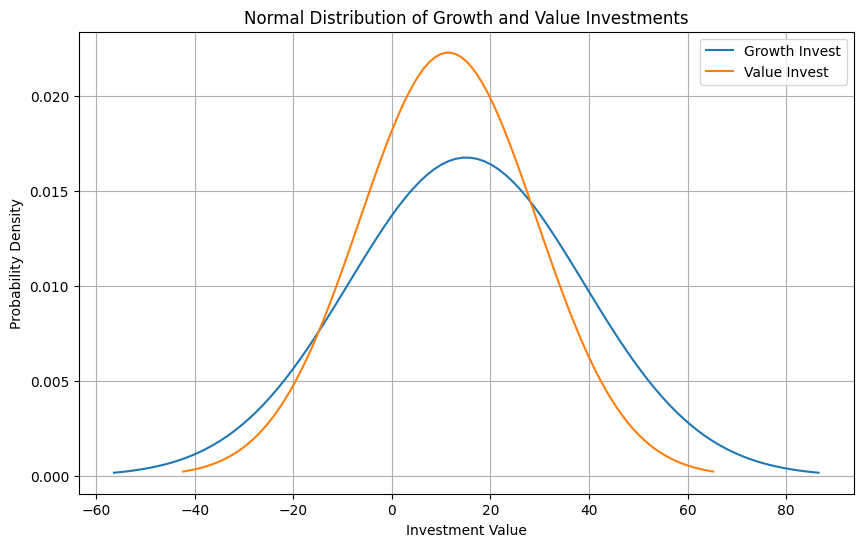

In [15]:
#Plot the normal distribution of the growth and value invests

def plot_normal_distribution(data, label):
    mean = data.mean()
    std_dev = data.std()
    x = np.linspace(mean - 3*std_dev, mean + 3*std_dev, 100)
    y = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std_dev)**2)
    plt.plot(x, y, label=label)

plt.figure(figsize=(10, 6))

plot_normal_distribution(df['Growth_Invest'], 'Growth Invest')
plot_normal_distribution(df['Value_Invest'], 'Value Invest')

plt.xlabel('Investment Value')
plt.ylabel('Probability Density')
plt.title('Normal Distribution of Growth and Value Investments')
plt.legend()
plt.grid(True)
plt.show()


Section 5: Detecting outliers

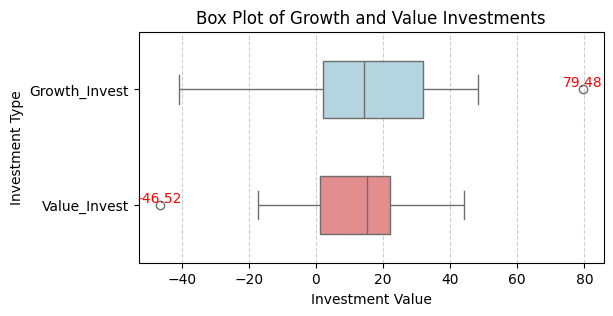

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df[['Growth_Invest', 'Value_Invest']]

# Identify and annotate outliers
plt.figure(figsize=(6, 3))
ax = sns.boxplot(data=data, orient="h", width=0.5, palette=["lightblue", "lightcoral"])

for i, column in enumerate(data.columns):
    Q1 = np.percentile(data[column], 25)
    Q3 = np.percentile(data[column], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[column][(data[column] < lower_bound) | (data[column] > upper_bound)]

    # Annotate outliers
    for outlier in outliers:
        ax.text(outlier, i, f"{outlier}", ha='center', va='bottom', fontsize=10, color='red')


plt.title('Box Plot of Growth and Value Investments')
plt.xlabel('Investment Value')
plt.ylabel('Investment Type')
plt.grid(axis="x", linestyle="--", alpha=0.6)



In [7]:
#Compute outliers using z-score and interpret the obtained values

# Calculate z-scores for 'Growth_Invest'
df['Growth_Invest_zscore'] = (df['Growth_Invest'] - df['Growth_Invest'].mean()) / df['Growth_Invest'].std()

# Identify outliers based on z-score threshold (e.g., |z-score| > 3)
outliers_growth = df[abs(df['Growth_Invest_zscore']) > 3]

print("Outliers in 'Growth_Invest' based on Z-score:")
print(outliers_growth)

# Interpretation using a simple formula:
# An observation is considered an outlier if its z-score is greater than 3 or less than -3.
# This means the observation is more than 3 standard deviations away from the mean.

# Calculate z-scores for 'Value_Invest'
df['Value_Invest_zscore'] = (df['Value_Invest'] - df['Value_Invest'].mean()) / df['Value_Invest'].std()

# Identify outliers based on z-score threshold (e.g., |z-score| > 3)
outliers_value = df[abs(df['Value_Invest_zscore']) > 3]

print("\nOutliers in 'Value_Invest' based on Z-score:")
outliers_value


Outliers in 'Growth_Invest' based on Z-score:
Empty DataFrame
Columns: [Growth_Invest, Value_Invest, Growth_Invest_zscore]
Index: []

Outliers in 'Value_Invest' based on Z-score:


,Growth_Invest,Value_Invest,Growth_Invest_zscore,Value_Invest_zscore
Year,,,,
2008,-40.9,-46.52,-2.351004,-3.234667


In [34]:
# Range
print(f"\nRange of Growth Invest: {df['Growth_Invest'].max() - df['Growth_Invest'].min()}")
print(f"Range of Value Invest: {df['Value_Invest'].max() - df['Value_Invest'].min()}")


# Summary Statistics
print("\nSummary Statistics:")
print(df[['Growth_Invest', 'Value_Invest']].describe())



Range of Growth Invest: 120.38
Range of Value Invest: 90.6

Summary Statistics:
       Growth_Invest  Value_Invest
count      35.000000     35.000000
mean       15.107429     11.444571
std        23.822771     17.919797
min       -40.900000    -46.520000
25%         2.130000      1.195000
50%        14.440000     15.090000
75%        31.995000     22.185000
max        79.480000     44.080000
